<a href="https://colab.research.google.com/github/Prakruthi2606/Potato_Disease_Prediction/blob/main/Potato_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Potato Leaf Disease Detection using Image Classification**

### **Project Description**

This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.

### **Load Dataset**

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Path to dataset files: /kaggle/input/potato-plant-diseases-data


## **1. Data Understanding**

Exploring the dataset

In [ ]:
import os
print(os.listdir(path))

['PlantVillage', 'PotatoPlants']


In [ ]:
print(os.listdir(os.path.join(path, "PlantVillage")))
print(os.listdir(os.path.join(path, "PotatoPlants")))

['PlantVillage']
['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


In [ ]:
data_dir = os.path.join(path, "PotatoPlants")
print(os.listdir(data_dir))

['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']


Visualizing sample images from each class

Potato___healthy:  152
Potato___Late_blight:  1000
Potato___Early_blight:  1000


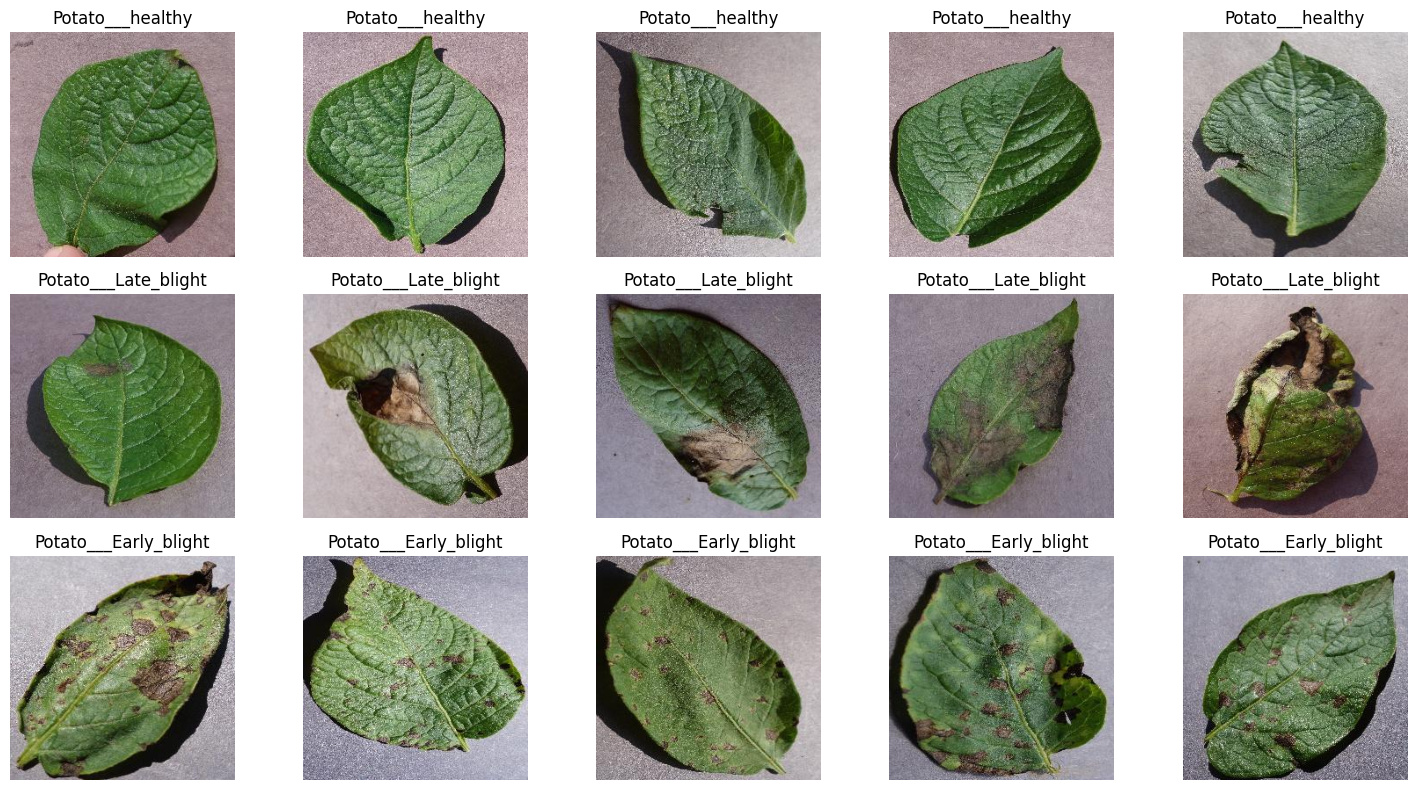

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

classes = ['Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

# Count images
for cls in classes:
    print(f"{cls}: ", len(os.listdir(os.path.join(data_dir, cls))))

# Show sample images
plt.figure(figsize=(15,8))

i = 1

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)[:5]   # 5 images per class

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            if os.path.isfile(img_path):
                img = Image.open(img_path)

                plt.subplot(3,5,i)   # 3 classes × 5 images
                plt.imshow(img)
                plt.title(class_name)
                plt.axis('off')

                i += 1

plt.tight_layout()
plt.show()

## **2. Data Preprocessing**

In [ ]:
import pandas as pd

df = []

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            if os.path.isfile(img_path):
                df.append([img_path, class_name])

# Create DataFrame
data = pd.DataFrame(df, columns=['img_path', 'labels'])

print(data.head())

                                            img_path            labels
0  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___healthy
1  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___healthy
2  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___healthy
3  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___healthy
4  /kaggle/input/potato-plant-diseases-data/Potat...  Potato___healthy


In [ ]:
# shuffle data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
data

,img_path,labels
0,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
1,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
3,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
4,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
...,...,...
2147,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight
2148,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
2149,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Late_blight
2150,/kaggle/input/potato-plant-diseases-data/Potat...,Potato___Early_blight


In [ ]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))
test_size = int(0.15*len(df))
print(f"train_size:{train_size} -----val_size:{val_size}----test_size:{test_size}")

train_data = data.iloc[:train_size]
# df.iloc[:,52500]
val_data = data.iloc[train_size:train_size + val_size]
# df.iloc[52500:52500+11250]
test_data = data.iloc[train_size + val_size:]
# df.iloc[52500+11250:]

# Display the sizes of each set
print(f'Training set size: {len(train_data)}')
print(f'Validation set size: {len(val_data)}')
print(f'Test set size: {len(test_data)}')

train_size:1506 -----val_size:322----test_size:322
Training set size: 1506
Validation set size: 322
Test set size: 324


In [ ]:
image_path = data["img_path"][0]
image = Image.open(image_path)
width, height = image.size
print(f"height,width:{height,width}")

height,width:(256, 256)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size = 32
img_height = 128
img_width = 128

In [ ]:
# Normalization
data_generator = ImageDataGenerator(
    rescale=1.0/255, # Normalization: Pixel values go from 0–255 → 0–1
    rotation_range=40, #Randomly rotates image up to ±40 degrees
    width_shift_range=0.2, #Moves image left/right by 20%
    height_shift_range=0.2, # Moves image up/down by 20%
    shear_range=0.2, # Slants the image (like pushing it sideways)
    zoom_range=0.2, # Zoom in/out randomly
    horizontal_flip=True, #Flips image left ↔ right
    fill_mode='nearest' #This fills those gaps using nearest pixels
)

In [ ]:
# train data
train_generator = data_generator.flow_from_dataframe(
  dataframe=train_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 1506 validated image filenames belonging to 3 classes.


In [ ]:
# test data
test_generator = data_generator.flow_from_dataframe(
  dataframe=test_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=True,
  seed=42
)

Found 324 validated image filenames belonging to 3 classes.


In [ ]:
# validation data
val_generator = data_generator.flow_from_dataframe(
  dataframe=val_data,
  x_col="img_path",
  y_col="labels",
  target_size=(img_height, img_width),
  batch_size=batch_size,
  class_mode="categorical",
  shuffle=False,
  seed=42
)

Found 322 validated image filenames belonging to 3 classes.


In [ ]:
for image_batch, labels_batch in train_generator:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_generator)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_generator:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_generator)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in test_generator:
    print(f"Test Shape: {image_batch.shape} (Batches = {len(test_generator)})")
    print(f"Test Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 128, 128, 3) (Batches = 48)
Train Label Shape: (32, 3)

Validation Shape: (32, 128, 128, 3) (Batches = 11)
Validation Label Shape: (32, 3)

Test Shape: (32, 128, 128, 3) (Batches = 11)
Test Label Shape: (32, 3)



Visualizing the augmentation done

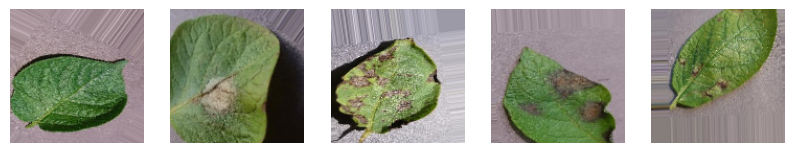

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

# **3. Model Building**

In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
cnn_model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

In [ ]:
cnn_model.compile(
    optimizer=Adam(),
    loss=categorical_crossentropy,
    metrics=['accuracy']
)

# **4. Model Training**

In [ ]:
CNN = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    verbose=1,
)


Epoch 1/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.4635 - loss: 0.9602 - val_accuracy: 0.7826 - val_loss: 0.8974
Epoch 2/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.5876 - loss: 0.8287 - val_accuracy: 0.7422 - val_loss: 0.6833
Epoch 3/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 984ms/step - accuracy: 0.7556 - loss: 0.6211 - val_accuracy: 0.8416 - val_loss: 0.4141
Epoch 4/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8453 - loss: 0.4074 - val_accuracy: 0.8727 - val_loss: 0.3106
Epoch 5/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8592 - loss: 0.3709 - val_accuracy: 0.9006 - val_loss: 0.2543
Epoch 6/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 970ms/step - accuracy: 0.8838 - loss: 0.3159 - val_accuracy: 0.9255 - val_loss: 0.1945
Epoch 7/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8400 - loss: 0.4033 - val_accuracy: 0.8820 - val_loss: 0.3108
Epoch 8/40
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 975ms/step - accuracy: 0.8865 - loss: 0.3111 - val_accuracy: 0.9224 - 

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 374ms/step - accuracy: 0.9834 - loss: 0.0520
Training accuracy: 0.9834
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 430ms/step - accuracy: 0.9815 - loss: 0.0516
Test accuracy: 0.9815


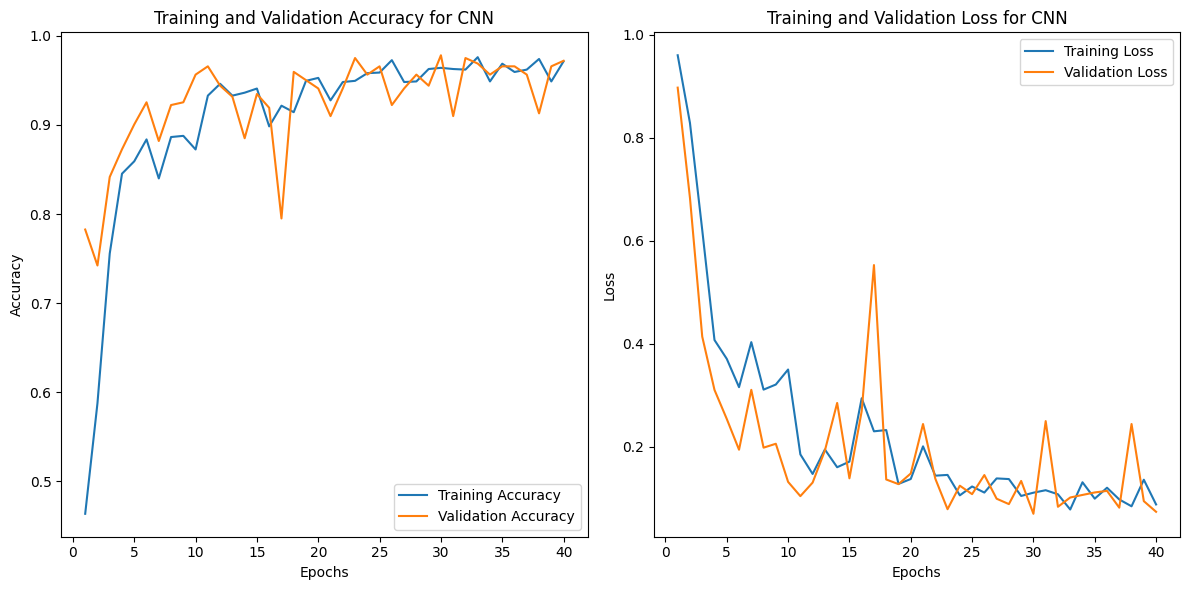

In [ ]:
# Retrieve metrics from the training history
acc = CNN.history['accuracy']
val_acc = CNN.history['val_accuracy']
loss = CNN.history['loss']
val_loss = CNN.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

## Testing the model performance by  making predictions for new images

In [ ]:
train_generator.class_indices

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [ ]:
val_generator.reset()

In [ ]:
test_generator.reset()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


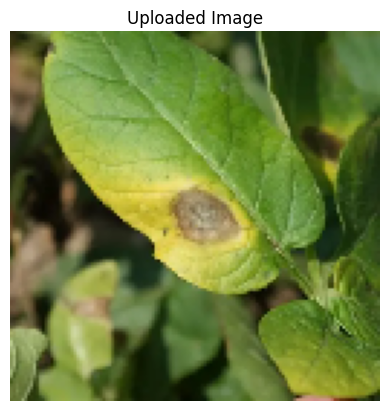

Predicted Class: 0
Predicted Class name: Potato___Early_blight


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

# Load image
img_path = "early_blight.webp"
img = image.load_img(img_path, target_size=(128,128))  # match your model
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = cnn_model.predict(img_array)

# Display image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Get class index
predicted_class = np.argmax(prediction)
print("Predicted Class:", predicted_class)

# Get class name
print("Predicted Class name:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


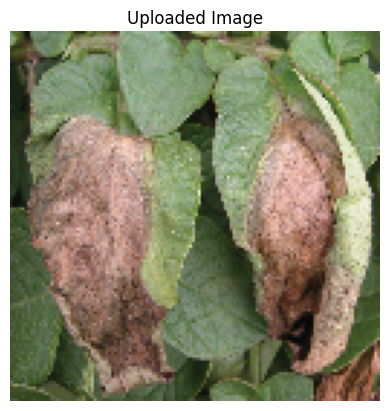

Predicted: Potato___Late_blight


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}

# Load image
img_path = "late.jpg"
img = image.load_img(img_path, target_size=(128,128))  # match your model
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = cnn_model.predict(img_array)

# Display image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Get class index
predicted_class = np.argmax(prediction)
print("Predicted:", class_names[predicted_class])

# **5. Model Evaluation**

In [ ]:
val_generator.reset()

In [ ]:
test_generator.reset()

In [ ]:
#accuracy
loss, accuracy = cnn_model.evaluate(val_generator)
print("Accuracy:", accuracy)
print("Loss:", loss)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.9752 - loss: 0.0593
Accuracy: 0.9751552939414978
Loss: 0.059292905032634735


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step
Confusion Matrix:
 [[137   3   0]
 [  2 158   1]
 [  0   4  17]]


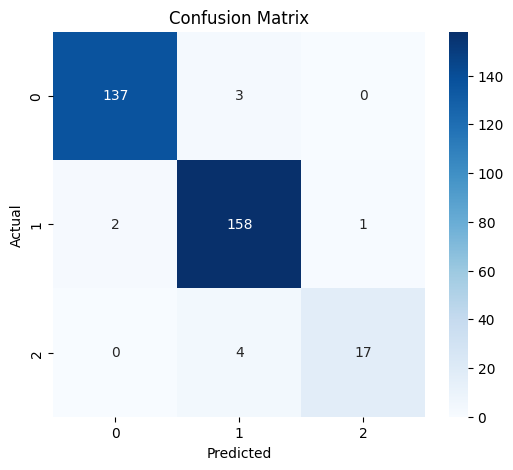

In [ ]:
# confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = cnn_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes


cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report

class_names = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                       precision    recall  f1-score   support

Potato___Early_blight       0.99      0.98      0.98       140
 Potato___Late_blight       0.96      0.98      0.97       161
     Potato___healthy       0.94      0.81      0.87        21

             accuracy                           0.97       322
            macro avg       0.96      0.92      0.94       322
         weighted avg       0.97      0.97      0.97       322



### **Save the model**

In [ ]:
cnn_model.save("potato_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("potato_model.h5")